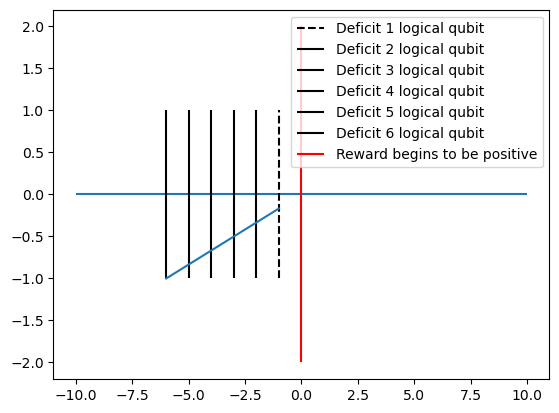

In [35]:
import numpy as np
import matplotlib.pyplot as plt
targetNumberOfQubits = 6
targetNumberOfQubitsArr = np.array([targetNumberOfQubits] * targetNumberOfQubits)
x = np.linspace(-6,1,20)
y = np.exp(x)
t = 1/x 
fig, ax = plt.subplots()
#ax.plot(x,y, color="blue", label = "exponent function" )
#ax.plot(x,x, color="blue", label = "linea rewrad" )
ax.hlines(0, -10, 10)
ax.vlines(-1, -1, 1, colors="black",linestyles="dashed", label = "Deficit 1 logical qubit")
ax.vlines(-2, -1, 1, colors="black", label = "Deficit 2 logical qubit")
ax.vlines(-3, -1, 1, colors="black", label = "Deficit 3 logical qubit")
ax.vlines(-4, -1, 1, colors="black", label = "Deficit 4 logical qubit")
ax.vlines(-5, -1, 1, colors="black", label = "Deficit 5 logical qubit")
ax.vlines(-6, -1, 1, colors="black", label = "Deficit 6 logical qubit")
ax.vlines(0, -2, 2, colors="red", label = "Reward begins to be positive")
#ax.plot(x,t, color = "green", label = "new negative reward")

deficitNumberOfQubits = np.array([-1,-2,-3,-4,-5,-6])


ax.plot(deficitNumberOfQubits,  deficitNumberOfQubits / targetNumberOfQubits)
ax.legend()




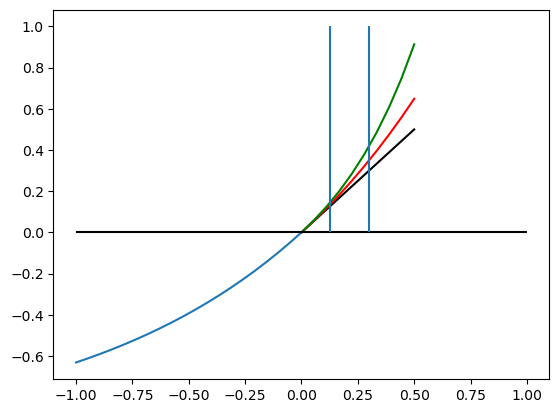

In [14]:
logicalQubits = np.linspace(-1,0,20)
reward = np.linspace(0,0.5,10)
y = np.exp(logicalQubits) -1
fig, ax = plt.subplots()
ax.plot(logicalQubits ,y)
ax.plot(reward, reward, color = "black")
ax.plot(reward, np.exp(reward) - 1, color = "red")
ax.plot(reward, np.exp(np.exp(reward) - 1)-1, color="green")
ax.plot()
ax.hlines(0,-1,1, colors="black")
ax.vlines(0.125, 0, 1)
ax.vlines(0.3, 0 , 1)

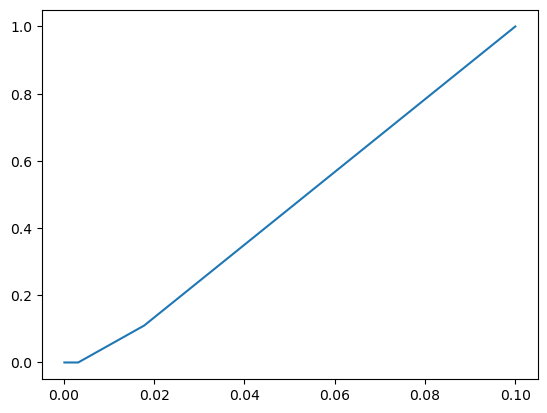

In [1]:
# Omer: Do not repurpose the following code, it's meant to check that BpOsdDecoder behaves correctly if the error probability changes

import numpy as np
from ldpc import BpOsdDecoder
from qecc.logicals import computeLogicals
from qecc.polynomialCodes import codes#["Hx_72_12_6"]
#from qecc.polynomialCodes import codes["Hz_72_12_6"]
from qecc.gf4 import integerToDualBinary
import matplotlib.pyplot as plt
Hx,Hz = codes["Hx_72_12_6"], codes["Hz_72_12_6"]

seed = 0
localRandom = np.random.RandomState(seed) 

logicalX, logicalZ = computeLogicals(Hx, Hz)

numberOfIterations = 50
numberOfSamples = 100

ms_scaling_factor = 0.625
#errorRange = np.linspace(0.0001,0.1,10).astype(float)
errorRange = np.geomspace(0.0001, 0.1, 5)
logicalErrorRate = np.zeros(len(errorRange))
bpDecoderHx=BpOsdDecoder(Hx,#the parity check matrix
                            error_rate=1.0,
                                #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
                            max_iter=numberOfIterations, #the maximum number of iterations for BP)
                            bp_method="ms",
                            ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
                            osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
                            osd_order=0 #the osd search depth
                            )
bpDecoderHz=BpOsdDecoder(Hz,#the parity check matrix
                            error_rate=1.0,
                            #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
                            max_iter=numberOfIterations, #the maximum number of iterations for BP)
                            bp_method="ms",
                            ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
                            osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
                            osd_order=0 #the osd search depth
                            )
for i in range(len(errorRange)):
    p = float(errorRange[i])
    bpDecoderHx.error_rate = p
    bpDecoderHz.error_rate = p
    # bpDecoderHx=BpOsdDecoder(Hx,#the parity check matrix
    #                         error_rate=p,
    #                             #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
    #                         max_iter=numberOfIterations, #the maximum number of iterations for BP)
    #                         bp_method="ms",
    #                         ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
    #                         osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
    #                         osd_order=0 #the osd search depth
    #                         )
    # bpDecoderHz=BpOsdDecoder(Hz,#the parity check matrix
    #                         error_rate=p,
    #                         #channel_probs= initialValues[:,1], #assign error_rate to each qubit. This will override "error_rate" input variable
    #                         max_iter=numberOfIterations, #the maximum number of iterations for BP)
    #                         bp_method="ms",
    #                         ms_scaling_factor=ms_scaling_factor, #min sum scaling factor. If set to zero the variable scaling factor method is used
    #                         osd_method="osd0", #the OSD method. Choose from:  1) "osd_e", "osd_cs", "osd0"
    #                         osd_order=0 #the osd search depth
    #                         )
    
    
    for _ in range(numberOfSamples):
        #Sample (some number of times) an error, which is a vector over {0,1,2,3} representing I,X,Z,Y (to be consistent check with the documentation in gf4.py)
        error = localRandom.choice([0,1,2,3], size=Hx.shape[1], replace=True, p=[1 - 3*p, p, p, p])
        errorX, errorZ = integerToDualBinary(error)
        #Calculate the syndrome for this error
        
        estimatedErrorX = bpDecoderHz.decode(Hz.dot(errorX)%2)
        estimatedErrorZ = bpDecoderHx.decode(Hx.dot(errorZ)%2)
        residualErrorX = (estimatedErrorX + errorX) % 2
        residualErrorZ = (estimatedErrorZ + errorZ) % 2
        # Check whether the residual error gives 0 syndrome:
        if not ( np.all((np.dot(Hx,residualErrorZ)) % 2 ==0) and np.all((np.dot(Hz, residualErrorX)%2) == 0)):
            #print("Decoder failure: the residual error does not give 0 syndrome, meaning the decoder is wrong")
            logicalErrorRate[i] += 1
        else: # So we are in the case that the residual error commutes with all stabilizers, i.e., it is in the normalizer. So let's check if it is a stabilizer (commutes with all logicals), or a logical error (anticommutes with some logical operator)
            if not ( np.all((np.dot(logicalZ,residualErrorX) % 2 )== 0) and np.all((np.dot(logicalX, residualErrorZ) % 2)==0)):
                #print(f"Logical error: the residual error commutes with all stabilizers but anticommutes with some logical operator")
                logicalErrorRate[i] += 1
logicalErrorRate = logicalErrorRate / numberOfSamples            
 
plt.plot(errorRange, logicalErrorRate)



108
Reward for code 108_8_10 is 0.0374625 engineered reward is: 0.375
144
Reward for code 144_12_12 is 0.037462499999999996 engineered reward is: 0.37499999999999994
288
Reward for code 288_12_18 is 0.041958 engineered reward is: 0.42
360
Reward for code 360_12_24 is 0.03996 engineered reward is: 0.4
72
Reward for code 72_12_6 is 0.035964 engineered reward is: 0.36000000000000004
756
Reward for code 756_16_34 is 0.0384615 engineered reward is: 0.385
90
Reward for code 90_8_10 is 0.035964 engineered reward is: 0.36000000000000004


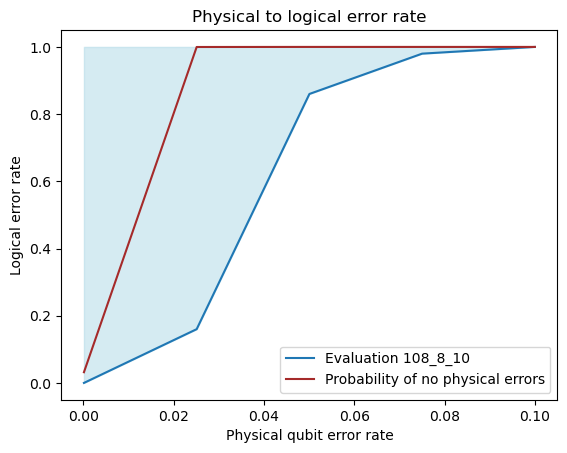

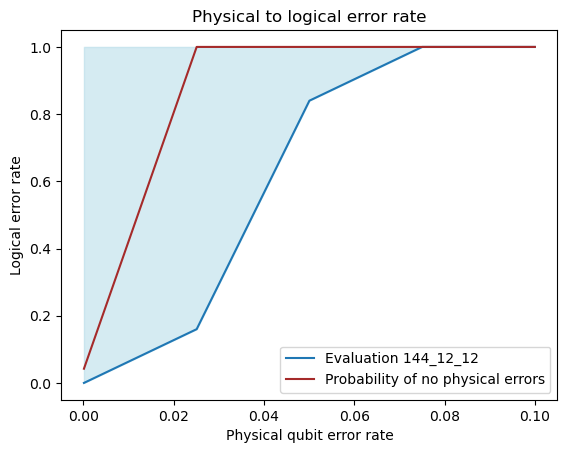

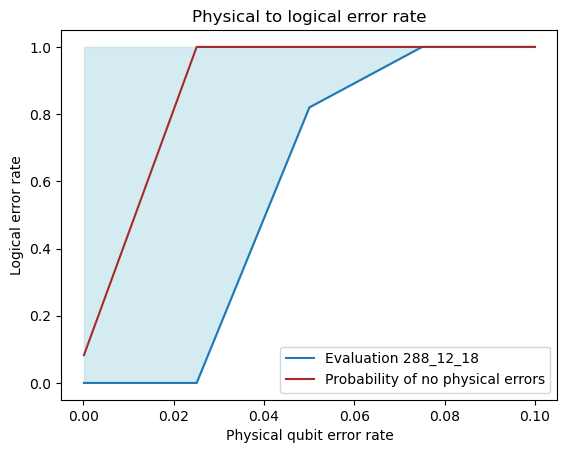

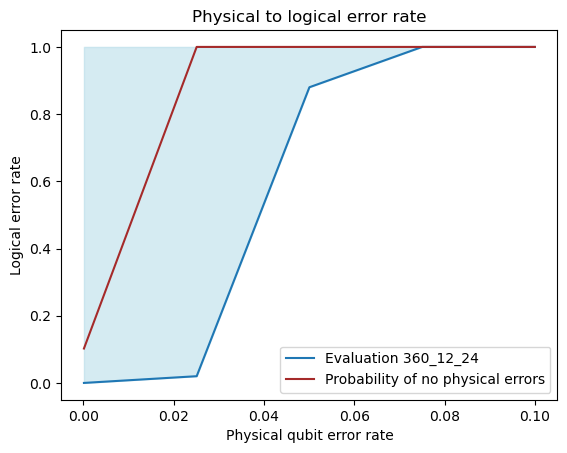

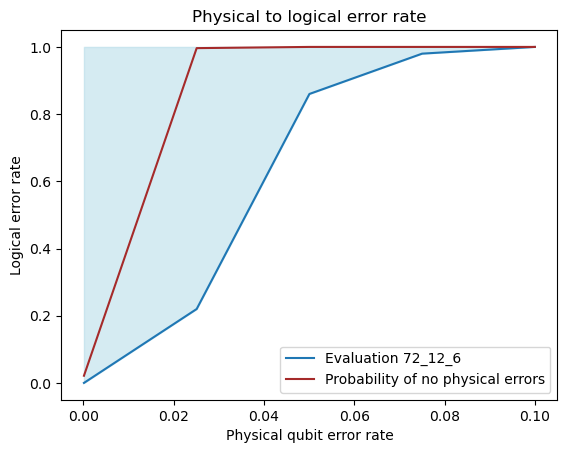

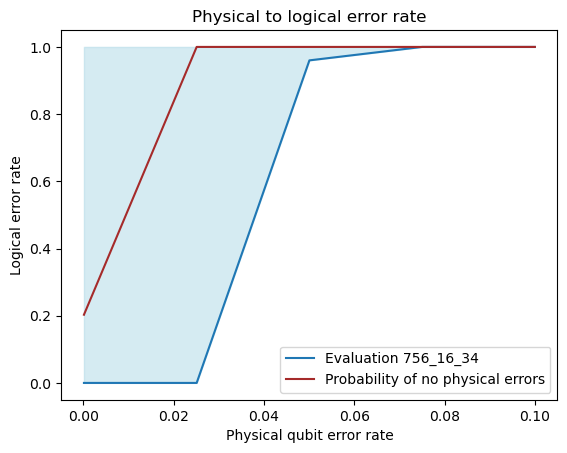

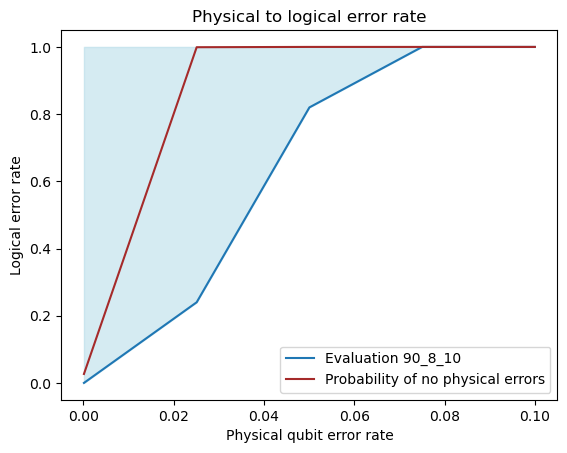

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
decoderEvaluationDataFolder = os.path.join(
    "c:/users/omer/qecc",
    "decoderComparisonData",
)
for dirpath, _dirs, files in os.walk(decoderEvaluationDataFolder):
    for fname in files:
        if fname.endswith(".npy") and fname.startswith("code_evaluation_for_bb_gym"):
            data = np.load(os.path.join(dirpath, fname), allow_pickle=True).item()
            #print(data)
            errorRange = data["errorRange"]
            logicalER = data["logicalER"]
            failureRate = data["decoderFER"]
            codeN = int(data["Code name"].split("_")[0])
            print(codeN)
            logicalER /= data["Number of samples"]
            fig, ax = plt.subplots()
            ax.plot(errorRange ,logicalER, label = f"Evaluation {data["Code name"]}") # FER is 0 for the bposd decoder by Roffe
            doNothing = 1 - (1 - 3 * errorRange)**codeN
            ax.plot(errorRange, doNothing, color = "brown", label = "Probability of no physical errors")
            reward = trapezoid(1 - logicalER, errorRange)
            rewardEngineered = reward / np.abs(np.min(errorRange) - np.max(errorRange))
            
            print(f"Reward for code {data["Code name"]} is {reward} engineered reward is: {rewardEngineered}") 
            #ax.hlines(1, np.min(errorRange), np.max(errorRange), color = "black", linestyle ="--")
            #ax.hlines(reward, np.min(errorRange), np.max(errorRange), color = "red", linestyle ="--")
            #ax.hlines(rewardEngineered, np.min(errorRange), np.max(errorRange), color = "green", linestyle ="--")
                #plot(reward, reward, color = "black")
            plt.fill_between(errorRange, logicalER, 0*errorRange + 1, color='lightblue', alpha=0.5)

            #plt.fill_between(errorRange, logicalER, doNothing, color='lightgreen', alpha=0.5)
            ax.set_xlabel("Physical qubit error rate")
            ax.set_ylabel("Logical error rate")
            ax.set_title("Physical to logical error rate")
            ax.legend()
            ax.plot()

            

            



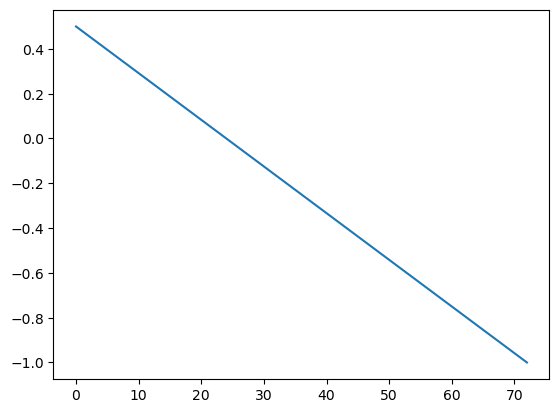

In [22]:

kMax = 24
kMin = 10
n = 72
kRange = np.linspace(0,n,n)
plt.plot(kRange, -1*(kRange-kMax)/(n-kMax))
    

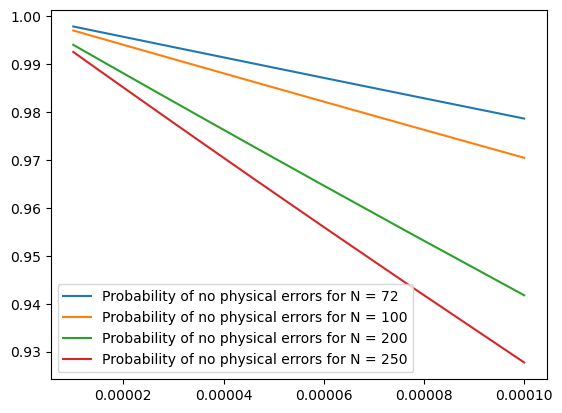

In [9]:
fig, ax = plt.subplots()
errorRange = np.geomspace(0.00001,0.0001, 10)
for i, codeN in enumerate ([72,100,200, 250]):
    doNothing = (1 - 3 * errorRange)**codeN
    ax.plot(errorRange, doNothing, color = f"C{i}", label = f"Probability of no physical errors for N = {codeN}")

#ax.set_xscale("log")
#ax.set_yscale("log")
ax.legend()


[0.001      0.00316228 0.01       0.03162278 0.1       ]
[0.0001   0.025075 0.05005  0.075025 0.1     ]


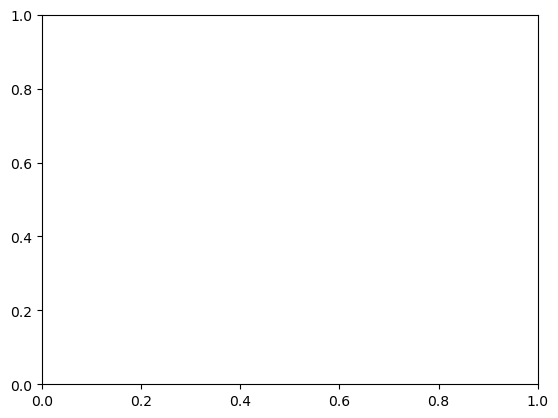

In [2]:
from qecc.utils import NAMED_ERROR_RANGES
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
print(NAMED_ERROR_RANGES["geometric5"])
print(NAMED_ERROR_RANGES["linear5"])

0 files would be affected
   ...
